# Theorem 1 pipeline: Austen drift, OCR/artifact reduction, and orthographic standardisation

This notebook builds a **single Austen-focused theorem-1 family** that shows both sides of recursive drift:

- **Negative / harmful:** vocabulary contraction and loss of rare clean words under recursive trigram drift  
- **Positive / beneficial:** reduction of sparse OCR/artifact noise and orthographic standardisation under the same drift dynamics

The notebook keeps the **original cleaned Austen corpus untouched**.  
All derived corpora with noise rates **0.5%, 1%, and 2%** are saved in separate folders.

## Families covered
1. **OCR / artifact reduction**
   - inject sparse OCR-like and transcription-like artifacts
   - track how artifact mass falls under drift

2. **Orthographic standardisation**
   - inject low-support hyphenated / variant spellings
   - track how drift removes low-support variants and increases canonical share

At the same time, the notebook records:
- total vocabulary size
- retained rare clean vocabulary
- active noise / variant types
- generation-by-generation drift curves for **α = 0.25, 0.5, 1.0**

## Recommended workflow
- First run **pilot mode** on a token-budgeted Austen subset
- Confirm checkpoints and resume work
- Then scale up by increasing token budget, generations, or enabling more families/rates


In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import pandas as pd
from IPython.display import display, Markdown


## Configuration

In [2]:
# Pilot-friendly defaults.
# Increase these later for full appendix runs.

PROJECT_ROOT = None  # or set explicitly to the Drift_and_selection repo root
TOKEN_BUDGET = 150_000
RATES = [0.005, 0.01, 0.02]          # 0.5%, 1%, 2%
ALPHAS = [0.25, 0.5, 1.0]
GENERATIONS = 8
MODE = "fixed_size_mix"              # or "growing_corpus"

BASE_SEED = 12345
LOWERCASE = True

# RUN_BUILD_DERIVED_CORPORA = True
# RUN_OCR_FAMILY = False
# RUN_ORTHO_FAMILY = False

FORCE_REBUILD_DERIVED = False
FORCE_REBUILD_RUNS = False


RUN_BUILD_DERIVED_CORPORA = True
RUN_OCR_FAMILY = False
RUN_ORTHO_FAMILY = True
RUN_FULL_FAMILY_GRID = False   # pilot: only first rate (0.5%)


# Turn this on only when you actually want all families/rates to run.
RUN_FULL_FAMILY_GRID = False

print({
    "TOKEN_BUDGET": TOKEN_BUDGET,
    "RATES": RATES,
    "ALPHAS": ALPHAS,
    "GENERATIONS": GENERATIONS,
    "MODE": MODE,
    "RUN_BUILD_DERIVED_CORPORA": RUN_BUILD_DERIVED_CORPORA,
    "RUN_OCR_FAMILY": RUN_OCR_FAMILY,
    "RUN_ORTHO_FAMILY": RUN_ORTHO_FAMILY,
    "RUN_FULL_FAMILY_GRID": RUN_FULL_FAMILY_GRID,
})


{'TOKEN_BUDGET': 150000, 'RATES': [0.005, 0.01, 0.02], 'ALPHAS': [0.25, 0.5, 1.0], 'GENERATIONS': 8, 'MODE': 'fixed_size_mix', 'RUN_BUILD_DERIVED_CORPORA': True, 'RUN_OCR_FAMILY': False, 'RUN_ORTHO_FAMILY': True, 'RUN_FULL_FAMILY_GRID': False}


## Import the helper module and discover repository paths

In [3]:
# Robust import bootstrap: locate repo and add GitHub/src to sys.path.
import importlib.util

def _discover_repo_root(start: Path, explicit_root=None) -> Path | None:
    if explicit_root:
        p = Path(explicit_root).expanduser().resolve()
        if (p / "GitHub" / "src").exists():
            return p
    for p in [start.resolve(), *start.resolve().parents]:
        if (p / "GitHub" / "src").exists():
            return p
    # fallback: common local location under Documents
    docs = Path.home() / "Documents"
    fallback = docs / "ChatGpt_codex_folder" / "Drift_and_selection"
    if (fallback / "GitHub" / "src").exists():
        return fallback
    return None

repo_root = _discover_repo_root(Path.cwd(), PROJECT_ROOT)
if repo_root is None:
    raise RuntimeError("Could not locate repository root containing GitHub/src")

src_root = repo_root / "GitHub" / "src"
pkg_root = src_root / "drift_selection"

for candidate in [src_root, pkg_root, Path.cwd(), Path.cwd().parent]:
    c = str(candidate)
    if candidate.exists() and c not in sys.path:
        sys.path.insert(0, c)

print("[import] cwd=", Path.cwd())
print("[import] repo_root=", repo_root)
print("[import] src_root=", src_root)

try:
    from drift_selection.theorem1_noise_standardization import (
        theorem1_noise_paths,
        load_austen_sentences,
        downsample_sentences_to_token_budget,
        compute_clean_reference_stats,
        build_derived_corpus_family,
        load_derived_sentences,
        run_family_experiment_grid,
        plot_family_grid,
        plot_combined_vocabulary,
        save_sentence_state,
        save_fig,
        codex_instructions,
    )
except ModuleNotFoundError:
    helper_file = pkg_root / "theorem1_noise_standardization.py"
    if not helper_file.exists():
        raise
    spec = importlib.util.spec_from_file_location("theorem1_noise_standardization", helper_file)
    module = importlib.util.module_from_spec(spec)
    assert spec and spec.loader
    spec.loader.exec_module(module)
    theorem1_noise_paths = module.theorem1_noise_paths
    load_austen_sentences = module.load_austen_sentences
    downsample_sentences_to_token_budget = module.downsample_sentences_to_token_budget
    compute_clean_reference_stats = module.compute_clean_reference_stats
    build_derived_corpus_family = module.build_derived_corpus_family
    load_derived_sentences = module.load_derived_sentences
    run_family_experiment_grid = module.run_family_experiment_grid
    plot_family_grid = module.plot_family_grid
    plot_combined_vocabulary = module.plot_combined_vocabulary
    save_sentence_state = module.save_sentence_state
    save_fig = module.save_fig
    codex_instructions = module.codex_instructions

paths = theorem1_noise_paths(PROJECT_ROOT)
paths


[import] cwd= /Users/sorenriis/Documents/ChatGpt_codex_folder/Drift_and_selection/GitHub/notebooks/active
[import] repo_root= /Users/sorenriis/Documents/ChatGpt_codex_folder/Drift_and_selection
[import] src_root= /Users/sorenriis/Documents/ChatGpt_codex_folder/Drift_and_selection/GitHub/src


{'root': PosixPath('/Users/sorenriis/Documents/ChatGpt_codex_folder/Drift_and_selection'),
 'github': PosixPath('/Users/sorenriis/Documents/ChatGpt_codex_folder/Drift_and_selection/GitHub'),
 'corpora': PosixPath('/Users/sorenriis/Documents/ChatGpt_codex_folder/Drift_and_selection/GitHub/corpora'),
 'raw': PosixPath('/Users/sorenriis/Documents/ChatGpt_codex_folder/Drift_and_selection/GitHub/corpora/raw'),
 'cleaned': PosixPath('/Users/sorenriis/Documents/ChatGpt_codex_folder/Drift_and_selection/GitHub/corpora/cleaned'),
 'notebooks': PosixPath('/Users/sorenriis/Documents/ChatGpt_codex_folder/Drift_and_selection/GitHub/notebooks/active'),
 'outputs': PosixPath('/Users/sorenriis/Documents/ChatGpt_codex_folder/Drift_and_selection/GitHub/data/outputs/theorem1_vocabulary_drift'),
 'runs': PosixPath('/Users/sorenriis/Documents/ChatGpt_codex_folder/Drift_and_selection/GitHub/data/outputs/theorem1_standardization/runs'),
 'metrics': PosixPath('/Users/sorenriis/Documents/ChatGpt_codex_folder/Dr

## Load the cleaned Austen corpus and create a working subset

In [4]:
austen_sentences_full = load_austen_sentences(PROJECT_ROOT, lowercase=LOWERCASE)
full_token_count = sum(len(s) for s in austen_sentences_full)

print(f"Loaded Austen corpus with {len(austen_sentences_full):,} sentences and {full_token_count:,} tokens.")

# IMPORTANT: the original cleaned corpus remains untouched.
# We create a working subset for pilot-scale theorem-1 experiments.
austen_sentences_base = downsample_sentences_to_token_budget(
    austen_sentences_full,
    token_budget=TOKEN_BUDGET,
    seed=BASE_SEED,
)

base_token_count = sum(len(s) for s in austen_sentences_base)
print(f"Working Austen subset: {len(austen_sentences_base):,} sentences, {base_token_count:,} tokens.")

base_state_dir = paths["out_root"] / "base_corpora"
base_state_dir.mkdir(parents=True, exist_ok=True)
base_state_path = base_state_dir / f"austen_base_subset_{TOKEN_BUDGET}.txt.gz"
save_sentence_state(base_state_path, austen_sentences_base)
print(f"Saved base working subset to: {base_state_path}")


[corpus] Found existing cleaned corpus, reusing: /Users/sorenriis/Documents/ChatGpt_codex_folder/Drift_and_selection/GitHub/corpora/cleaned/jane_austen/jane_austen_combined_clean.txt
Loaded Austen corpus with 28,587 sentences and 601,081 tokens.
Working Austen subset: 7,121 sentences, 149,968 tokens.
Saved base working subset to: /Users/sorenriis/Documents/ChatGpt_codex_folder/Drift_and_selection/GitHub/data/outputs/theorem1_standardization/base_corpora/austen_base_subset_150000.txt.gz


## Clean-reference statistics

In [5]:
clean_ref = compute_clean_reference_stats(austen_sentences_base, rare_threshold=3)
pd.DataFrame([{
    "clean_token_count": clean_ref["clean_token_count"],
    "clean_vocab_size": clean_ref["clean_vocab_size"],
    "clean_rare_vocab_size": clean_ref["clean_rare_vocab_size"],
}])


,clean_token_count,clean_vocab_size,clean_rare_vocab_size
0,149968,8204,5316


## Build the derived corpora (kept separate by family and rate)

In [6]:
if RUN_BUILD_DERIVED_CORPORA:
    ocr_summary = build_derived_corpus_family(
        austen_sentences_base,
        family="ocr_artifacts",
        rates=RATES,
        base_seed=BASE_SEED,
        project_root=PROJECT_ROOT,
        overwrite=FORCE_REBUILD_DERIVED,
    )
    ortho_summary = build_derived_corpus_family(
        austen_sentences_base,
        family="orthographic_variants",
        rates=RATES,
        base_seed=BASE_SEED + 1000,
        project_root=PROJECT_ROOT,
        overwrite=FORCE_REBUILD_DERIVED,
    )
else:
    ocr_summary = pd.read_csv(paths["derived"] / "ocr_artifacts" / "derived_corpora_summary.csv")
    ortho_summary = pd.read_csv(paths["derived"] / "orthographic_variants" / "derived_corpora_summary.csv")

display(Markdown("### OCR / artifact derived corpora"))
display(ocr_summary)

display(Markdown("### Orthographic-variant derived corpora"))
display(ortho_summary)


### OCR / artifact derived corpora

,candidate_positions,changed_fraction_of_candidates,changed_positions,created_at,family,noise_token_set,original_to_noisy,rate,seed,sentence_count,sentences_path,token_count
0,41866,0.005374,225,2026-03-05T09:19:14Z,ocr_artifacts,"[advantag, afraicl, agitatecl, alvvays, ansvve...","{'advantage': {'advantag': 1}, 'afraid': {'afr...",0.005,12345,7121,/Users/sorenriis/Documents/ChatGpt_codex_folde...,149970
1,41866,0.009865,413,2026-03-05T09:19:14Z,ocr_artifacts,"[acciclental, aclmiration, aclventure, affecte...","{'accidental': {'acciclental': 1}, 'admiration...",0.010,12346,7121,/Users/sorenriis/Documents/ChatGpt_codex_folde...,149969
2,41866,0.020040,839,2026-03-05T09:19:14Z,ocr_artifacts,"[absolut, accorclingly, accornpanying, acknovv...","{'absolute': {'absolut': 2}, 'accompanying': {...",0.020,12347,7121,/Users/sorenriis/Documents/ChatGpt_codex_folde...,149972


### Orthographic-variant derived corpora

,candidate_positions,changed_fraction_of_candidates,changed_positions,created_at,family,rate,seed,sentence_count,sentences_path,token_count,variant_families,variant_map
0,945,0.001058,1,2026-03-05T09:19:15Z,orthographic_variants,0.005,13345,7121,/Users/sorenriis/Documents/ChatGpt_codex_folde...,149968,"{'anyone': ['any-one', 'anyone'], 'anything': ...","{'anyone': 'any-one', 'anything': 'any-thing',..."
1,945,0.007407,7,2026-03-05T09:19:15Z,orthographic_variants,0.010,13346,7121,/Users/sorenriis/Documents/ChatGpt_codex_folde...,149968,"{'anyone': ['any-one', 'anyone'], 'anything': ...","{'anyone': 'any-one', 'anything': 'any-thing',..."
2,945,0.016931,16,2026-03-05T09:19:15Z,orthographic_variants,0.020,13347,7121,/Users/sorenriis/Documents/ChatGpt_codex_folde...,149968,"{'anyone': ['any-one', 'anyone'], 'anything': ...","{'anyone': 'any-one', 'anything': 'any-thing',..."


## Quick sanity-check samples from the derived corpora

In [7]:
for family in ["ocr_artifacts", "orthographic_variants"]:
    print(f"\n=== FAMILY: {family} ===")
    for rate in RATES:
        sentences, meta = load_derived_sentences(family, rate, project_root=PROJECT_ROOT)
        print(f"rate={rate:.3%}  changed_positions={meta.get('changed_positions')}  token_count={meta.get('token_count')}")
        preview = " ".join(sentences[0][:25]) if sentences else ""
        print("sample:", preview)



=== FAMILY: ocr_artifacts ===
rate=0.500%  changed_positions=225  token_count=149970
sample: wickham of course wanted more than he could get but at length was reduced to be reasonable
rate=1.000%  changed_positions=413  token_count=149969
sample: wickham of course wanted more than he could get but at length was reduced to be reasonable
rate=2.000%  changed_positions=839  token_count=149972
sample: wickham of course wanted more than he could get but at length was reduced to be reasonable

=== FAMILY: orthographic_variants ===
rate=0.500%  changed_positions=1  token_count=149968
sample: wickham of course wanted more than he could get but at length was reduced to be reasonable
rate=1.000%  changed_positions=7  token_count=149968
sample: wickham of course wanted more than he could get but at length was reduced to be reasonable
rate=2.000%  changed_positions=16  token_count=149968
sample: wickham of course wanted more than he could get but at length was reduced to be reasonable


## Dry-run cost estimate

This estimate is deliberately rough, but it is useful before launching long runs.
For fixed-size drift, each generation generates approximately:

\[
\alpha \times M
\]

synthetic tokens, where \(M\) is the base token budget.

The OCR and orthographic families can be run separately; both support checkpoint/resume.


In [8]:
base_M = base_token_count
rows = []
for alpha in ALPHAS:
    synthetic_per_gen = int(round(alpha * base_M))
    rows.append({
        "alpha": alpha,
        "synthetic_tokens_per_generation": synthetic_per_gen,
        "synthetic_tokens_over_run": synthetic_per_gen * GENERATIONS,
    })
estimate_df = pd.DataFrame(rows)
display(estimate_df)
print("Full two-family full-rate run will multiply this by:")
print(f"  families = 2, rates = {len(RATES)}, alpha values = {len(ALPHAS)}")


,alpha,synthetic_tokens_per_generation,synthetic_tokens_over_run
0,0.25,37492,299936
1,0.50,74984,599872
2,1.00,149968,1199744


Full two-family full-rate run will multiply this by:
  families = 2, rates = 3, alpha values = 3


## Run the OCR / artifact-reduction family

In [9]:
ocr_df = None
if RUN_OCR_FAMILY:
    ocr_df = run_family_experiment_grid(
        clean_anchor_sentences=austen_sentences_base,
        family="ocr_artifacts",
        rates=RATES if RUN_FULL_FAMILY_GRID else [RATES[0]],
        alphas=ALPHAS,
        mode=MODE,
        generations=GENERATIONS,
        token_budget=TOKEN_BUDGET,
        base_seed=BASE_SEED,
        project_root=PROJECT_ROOT,
    )
    display(ocr_df.head())
else:
    print("RUN_OCR_FAMILY is False; skipping execution.")


RUN_OCR_FAMILY is False; skipping execution.


## Run the orthographic-standardisation family

In [10]:
ortho_df = None
if RUN_ORTHO_FAMILY:
    ortho_df = run_family_experiment_grid(
        clean_anchor_sentences=austen_sentences_base,
        family="orthographic_variants",
        rates=RATES if RUN_FULL_FAMILY_GRID else [RATES[0]],
        alphas=ALPHAS,
        mode=MODE,
        generations=GENERATIONS,
        token_budget=TOKEN_BUDGET,
        base_seed=BASE_SEED + 5000,
        project_root=PROJECT_ROOT,
    )
    display(ortho_df.head())
else:
    print("RUN_ORTHO_FAMILY is False; skipping execution.")


family=orthographic_variants:rates:   0%|          | 0/1 [00:00<?, ?rate/s]

orthographic_variants:alpha-grid:   0%|          | 0/3 [00:00<?, ?alpha/s]

orthographic_variants:rate=0.005:alpha=0.25:   0%|          | 0/9 [00:00<?, ?gen/s]

orthographic_variants:rate=0.005:alpha=0.5:   0%|          | 0/9 [00:00<?, ?gen/s]

orthographic_variants:rate=0.005:alpha=1:   0%|          | 0/9 [00:00<?, ?gen/s]

,run_id,generation,family,rate,alpha,mode,token_count,vocab_size,head_vocab_size,distinct_bigram_contexts,...,active_count_threshold,retained_clean_vocab_count,retained_clean_vocab_share,retained_rare_clean_vocab_count,retained_rare_clean_vocab_share,orthographic_family_mass,orthographic_canonical_share,orthographic_variant_share,orthographic_active_variant_forms,orthographic_active_families
0,1,0,orthographic_variants,0.005,0.25,fixed_size_mix,149968,8205,8205,66036,...,2,8204,1.000000,5316,1.000000,975,0.968205,0.031795,5,15
1,1,1,orthographic_variants,0.005,0.25,fixed_size_mix,149968,6667,6667,46353,...,2,6667,0.812652,3789,0.712754,934,0.960385,0.039615,3,13
2,1,2,orthographic_variants,0.005,0.25,fixed_size_mix,149968,6720,6720,46514,...,2,6720,0.819113,3845,0.723288,984,0.969512,0.030488,3,14
3,1,3,orthographic_variants,0.005,0.25,fixed_size_mix,149972,6692,6692,46330,...,2,6692,0.815700,3819,0.718397,1008,0.967262,0.032738,4,15
4,1,4,orthographic_variants,0.005,0.25,fixed_size_mix,149968,6717,6717,46494,...,2,6717,0.818747,3840,0.722348,1036,0.972008,0.027992,4,15


## Load already-saved metrics if runs have completed earlier

In [11]:
ocr_metrics_path = paths["metrics"] / f"jane_austen__ocr_artifacts__{MODE}_grid_metrics.csv"
ortho_metrics_path = paths["metrics"] / f"jane_austen__orthographic_variants__{MODE}_grid_metrics.csv"

if ocr_df is None and ocr_metrics_path.exists():
    ocr_df = pd.read_csv(ocr_metrics_path)
if ortho_df is None and ortho_metrics_path.exists():
    ortho_df = pd.read_csv(ortho_metrics_path)

print("OCR metrics path:", ocr_metrics_path, "exists=", ocr_metrics_path.exists())
print("ORTHO metrics path:", ortho_metrics_path, "exists=", ortho_metrics_path.exists())


OCR metrics path: /Users/sorenriis/Documents/ChatGpt_codex_folder/Drift_and_selection/GitHub/data/outputs/theorem1_standardization/metrics/jane_austen__ocr_artifacts__fixed_size_mix_grid_metrics.csv exists= False
ORTHO metrics path: /Users/sorenriis/Documents/ChatGpt_codex_folder/Drift_and_selection/GitHub/data/outputs/theorem1_standardization/metrics/jane_austen__orthographic_variants__fixed_size_mix_grid_metrics.csv exists= True


## Plot the OCR / artifact family

In [12]:
if ocr_df is not None and len(ocr_df):
    fig = plot_family_grid(
        ocr_df,
        family="ocr_artifacts",
        out_path_base=paths["figures_std"] / "austen_ocr_artifact_family",
    )
    fig
else:
    print("No OCR metrics available yet.")


No OCR metrics available yet.


## Plot the orthographic-standardisation family

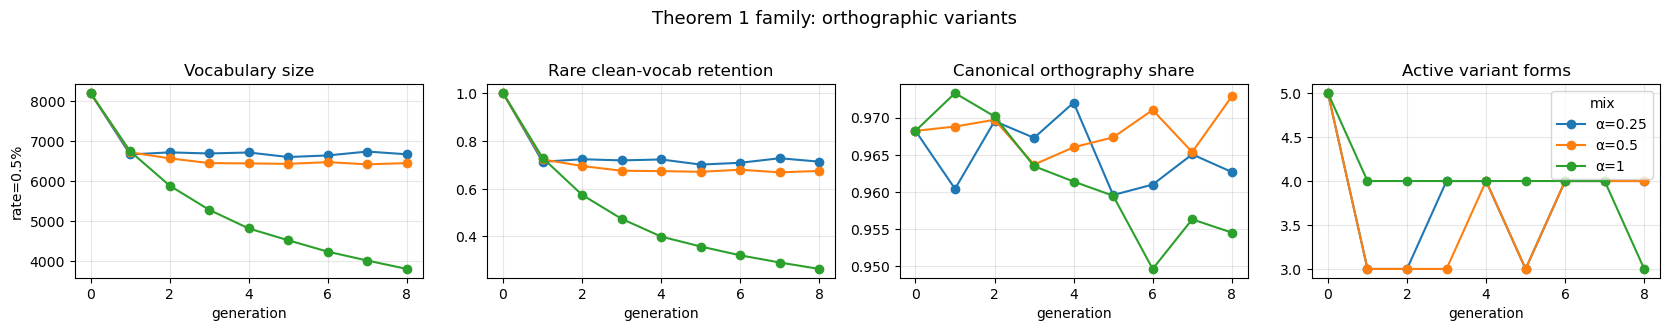

In [13]:
if ortho_df is not None and len(ortho_df):
    fig = plot_family_grid(
        ortho_df,
        family="orthographic_variants",
        out_path_base=paths["figures_std"] / "austen_orthographic_family",
    )
    fig
else:
    print("No orthographic metrics available yet.")


## Combined vocabulary-reduction view

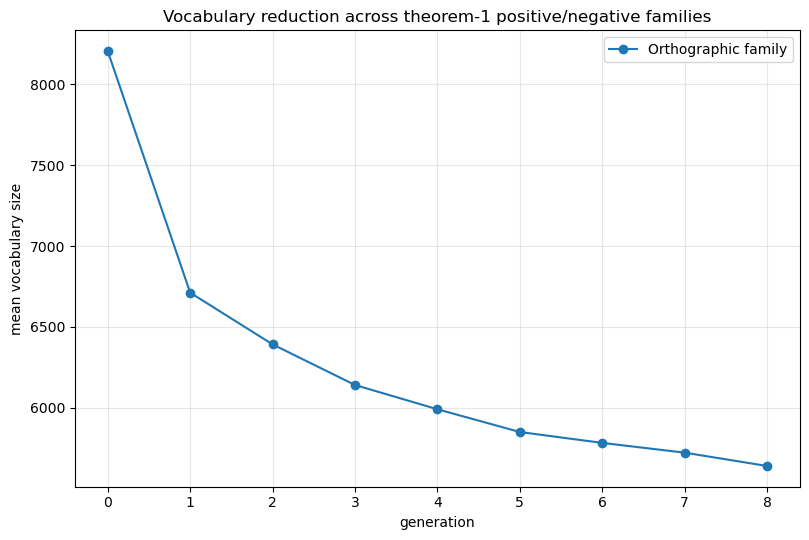

In [14]:
frames = []
labels = []
if ocr_df is not None and len(ocr_df):
    frames.append(ocr_df)
    labels.append("OCR/artifact family")
if ortho_df is not None and len(ortho_df):
    frames.append(ortho_df)
    labels.append("Orthographic family")

if frames:
    fig = plot_combined_vocabulary(
        frames,
        labels,
        out_path_base=paths["figures_std"] / "austen_combined_vocabulary_reduction",
    )
    fig
else:
    print("No completed family metrics available yet.")


## Save compact appendix-ready summaries

In [15]:
summary_rows = []
for label, df in [("ocr_artifacts", ocr_df), ("orthographic_variants", ortho_df)]:
    if df is None or not len(df):
        continue
    final = df.groupby(["family", "rate", "alpha"], as_index=False).apply(lambda g: g.sort_values("generation").iloc[-1]).reset_index(drop=True)
    final["label"] = label
    summary_rows.append(final)

if summary_rows:
    final_summary = pd.concat(summary_rows, ignore_index=True)
    final_summary_path = paths["metrics"] / f"austen_theorem1_standardization__{MODE}__final_summary.csv"
    final_summary.to_csv(final_summary_path, index=False)
    display(final_summary)
    print(f"Saved summary to: {final_summary_path}")
else:
    print("No completed runs yet; summary not written.")


,family,rate,alpha,run_id,generation,mode,token_count,vocab_size,head_vocab_size,distinct_bigram_contexts,...,retained_clean_vocab_count,retained_clean_vocab_share,retained_rare_clean_vocab_count,retained_rare_clean_vocab_share,orthographic_family_mass,orthographic_canonical_share,orthographic_variant_share,orthographic_active_variant_forms,orthographic_active_families,label
0,orthographic_variants,0.005,0.25,1,8,fixed_size_mix,149968,6672,6672,46019,...,6672,0.813262,3791,0.713130,991,0.962664,0.037336,4,15,orthographic_variants
1,orthographic_variants,0.005,0.50,2,8,fixed_size_mix,149973,6451,6451,43668,...,6451,0.786324,3585,0.674379,994,0.972837,0.027163,4,14,orthographic_variants
2,orthographic_variants,0.005,1.00,3,8,fixed_size_mix,149968,3798,3798,18362,...,3797,0.462823,1404,0.264108,879,0.954494,0.045506,3,13,orthographic_variants


Saved summary to: /Users/sorenriis/Documents/ChatGpt_codex_folder/Drift_and_selection/GitHub/data/outputs/theorem1_standardization/metrics/austen_theorem1_standardization__fixed_size_mix__final_summary.csv


## Notes for Codex / repository placement

In [16]:
print(codex_instructions())


Place the notebook at `Drift_and_selection/GitHub/notebooks/active/19_theorem1_austen_noise_and_standardization.ipynb` and the helper at `Drift_and_selection/GitHub/src/drift_selection/theorem1_noise_standardization.py`. Keep original cleaned Austen text untouched. Save derived corpora under `Drift_and_selection/GitHub/data/outputs/theorem1_standardization/derived_corpora/` with separate folders for `ocr_artifacts` and `orthographic_variants` at rates 0.5%, 1%, and 2%. Save run checkpoints under `.../runs/`, metrics under `.../metrics/`, figures under `Drift_and_selection/GitHub/figures/appendix/theorem1_standardization/`, and SQLite metadata in `Drift_and_selection/GitHub/data/databases/theorem1_standardization.sqlite`.


## Recommended execution order

1. Build/load the Austen base subset  
2. Build the six derived corpora  
   - OCR artifacts at 0.5%, 1%, 2%
   - orthographic variants at 0.5%, 1%, 2%
3. Run one **pilot** family first  
   - e.g. OCR artifacts at 0.5% with α = 0.25, 0.5, 1.0
4. Confirm checkpoints and resume work
5. Then enable the full family grid
6. Finally, compare the positive and negative theorem-1 metrics together

This notebook is designed so the **original cleaned Austen corpus remains untouched**, while all modified corpora and drift runs are stored separately.
